# (1+1)D Allen–Cahn Equation with Periodic Boundary Conditions (Soft Form)

This notebook solves the **Allen–Cahn equation** using a Physics-Informed Neural Network (PINN)
with **soft periodic boundary conditions** enforced as a penalty term in the loss.

## Governing equation

$$u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0, \quad x \in [-1, 1],\ t \in [0, 1]$$

## Conditions

**Initial condition:**
$$u(0, x) = x^2 \cos(\pi x)$$

**Periodic boundary conditions (soft form):**
$$u(t, -1) = u(t, 1), \qquad u_x(t, -1) = u_x(t, 1)$$

## Strategy: penalty loss

Periodicity is enforced by adding penalty terms to the training loss:

$$\mathcal{L}_\text{periodic} = \lambda \left[\operatorname{mean}\bigl(|u(t,-1) - u(t,1)|^2\bigr)
+ \operatorname{mean}\bigl(|u_x(t,-1) - u_x(t,1)|^2\bigr)\right]$$

`domain.add_periodic(dim=1, ...)` creates the condition automatically — no manual array construction needed.


In [1]:
import pinns

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

## Domain & Boundary Conditions

Space-time domain: $(t, x) \in [0, 1] \times [-1, 1]$.

The initial condition is registered as a Dirichlet BC. The periodic BC is registered via
`add_periodic(dim=1, ...)` and is handled automatically by the trainer with no manual sampling.


In [2]:
domain = pinns.DomainCubic(
    space = [(-1.0, 1.0)],   # (x_min, x_max)
    time = [0.0,  1.0],   # (t_min, t_max)
)

domain.add_periodic(axis="x", name="periodic")

## PDE Residual

$$\mathcal{R} = u_t - 0.0001\, u_{xx} + 5u^3 - 5u = 0$$

In [3]:
problem = pinns.ProblemStrong(domain=domain, output_names=["u"])

def allen_cahn_residual(X, U, params, derivative=None):

    eps  = params['parameter']['eps']   # diffusion coefficient
    coef = params['parameter']['coef']  # coefficient of the reaction term

    u_t  = derivative(U, X, 0, (1,))         # (n,1)  ∂u/∂t   (col 1 = t)
    u_xx = derivative(U, X, 0, (0, 0))       # (n,1)  ∂²u/∂x² (col 0 = x)

    return u_t - eps * u_xx + coef * (U**3 - U)  # (n,1)

problem.add_inner(allen_cahn_residual, name="pde")

def u_initial(X):
    x = X[:, 0:1]
    return x**2 * jnp.cos(np.pi * x)

problem.add_initial(
    u_initial,
    name="initial"
)

problem.add_periodic(
    region="periodic", name="periodic", component=0, match_x_derivative=0
)

problem.add_parameter("eps", 1e-4)
problem.add_parameter("coef", 5.0)

ProblemStrong(domain=DomainCubic, n_dims=2, n_outputs=1, inner=1, boundary=1, initial=1, params=['eps', 'coef'], trainable=[])

### Reference Solution (pseudo-spectral adaptive Dopri5)

A high-accuracy reference is computed with `ModelSpectralSolver` + `AdaptiveIntegrator(IntegratorDopri5(), ...)`
(native Dormand-Prince 4(5) adaptive RK) in Fourier space with **2/3 dealiasing** (Orszag rule).

$$\partial_t \hat{u}_k = \underbrace{-\varepsilon k^2 \hat{u}_k}_{\text{linear}} + \underbrace{\mathcal{F}\{-\text{coef}(u^3 - u)\}}_{\text{nonlinear, dealiased}}$$

Available native integrators (no diffrax dependency):

| Class | Method | Step | Use case |
|-------|--------|------|----------|
| `IntegratorEuler` | Forward Euler | Fixed | Debugging / simple tests |
| `IntegratorDopri5` | Dormand-Prince 4(5) | Tableau only | Wrap in `AdaptiveIntegrator` |
| `IntegratorTsit5` | Tsitouras 4(5) | Tableau only | Wrap in `AdaptiveIntegrator` |
| `IntegratorRK4` | Classical RK4 | Fixed | Non-stiff, general |
| `IntegratorETD2RK` | ETD2RK | Fixed | Stiff spectral (exact linear part) |
| `IntegratorIMEX` | IMEX Euler | Fixed | Stiff, implicit-explicit |
| `AdaptiveIntegrator` | Adaptive loop | Adaptive | Wraps any tableau integrator |


Text(0.5, 1.0, 'Reference solution u(t,x)')

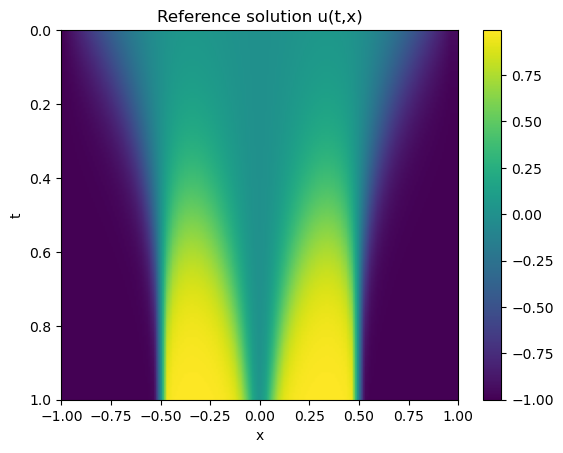

In [4]:
# ── Parameters ────────────────────────────────────────────────────────────────
eps_val  = 1e-4
coef_val = 5.0
Nx = 200
Nt  = 200

# ── DomainCubic ─────────────────────────────────────
domain_grid = pinns.DomainCubic(
    space=[(-1.0, 1.0)],
    time=(0.0, 1.0),
)

# Native adaptive Dormand-Prince 4(5) — no diffrax required
integrator_ac = pinns.IntegratorDopri5(
    rtol=1e-6, 
    atol=1e-8,
    dt0=1e-2,
    max_steps=2**12,      # 4096 upper bound; Allen-Cahn needs ~100-500 steps
)

model_ac = pinns.ModelSpectralSolver(domain_grid, ["u"], integrator_ac)

# Linear part: L_k = −ε k²   (p["parameter"] holds registered scalars)
model_ac.set_linear_op(
    lambda X, p: {"u": -p["parameter"]["eps"] * X**2}
)

# Nonlinear (source) part — fn(X, U, p): state-dependent, use set_source_fn
def ac_nonlinear(X, U, p):
    u = model_ac.inverse(U["u"])
    N_hat = model_ac.forward(-p["parameter"]["coef"] * (u**3 - u))
    return {"u": N_hat}

model_ac.set_source_fn(ac_nonlinear)
model_ac.add_parameter("eps",  eps_val)
model_ac.add_parameter("coef", coef_val)

# Initial condition: u(x, 0) = x² cos(πx)  — model_ac.x holds the spectral grid
model_ac.add_initial(model_ac.x**2 * jnp.cos(jnp.pi * model_ac.x))

# ── Forward solve (for plotting) ──────────────────────────────────────────────
U_sol = model_ac.solve()

# ── Visualize result ──────
x_ref  = np.linspace(-1.0, 1.0, Nx)
t_ref  = np.linspace(0.0, 1.0, Nt)
X, T = np.meshgrid(x_ref, t_ref)
X = np.stack([X.flatten(),T.flatten()], axis=1)

u_ref = model_ac.predict(X)

x_ref = np.array(model_ac.x)   # (Nx,) grid nodes for plotting
plt.imshow(u_ref.reshape(Nx, Nt), extent=(-1, 1, 1, 0), aspect='auto', cmap='viridis')
plt.colorbar(); plt.xlabel("x"); plt.ylabel("t"); plt.title("Reference solution u(t,x)")

## Network Architecture

A 3-hidden-layer MLP with 64 units per layer. Input size is 2 (t, x).
`normalize_input=True` normalises the raw (t, x) to [-1, 1] before feeding into the network.


In [5]:
network = pinns.create_model(
    domain, 1,
    features=pinns.FourierFeatures(128, sigma=1),
    core=pinns.FNN([64,64,64], output_activation="tanh"),
)

## Training

Starting training for 50000 epochs (JIT-compiled)...


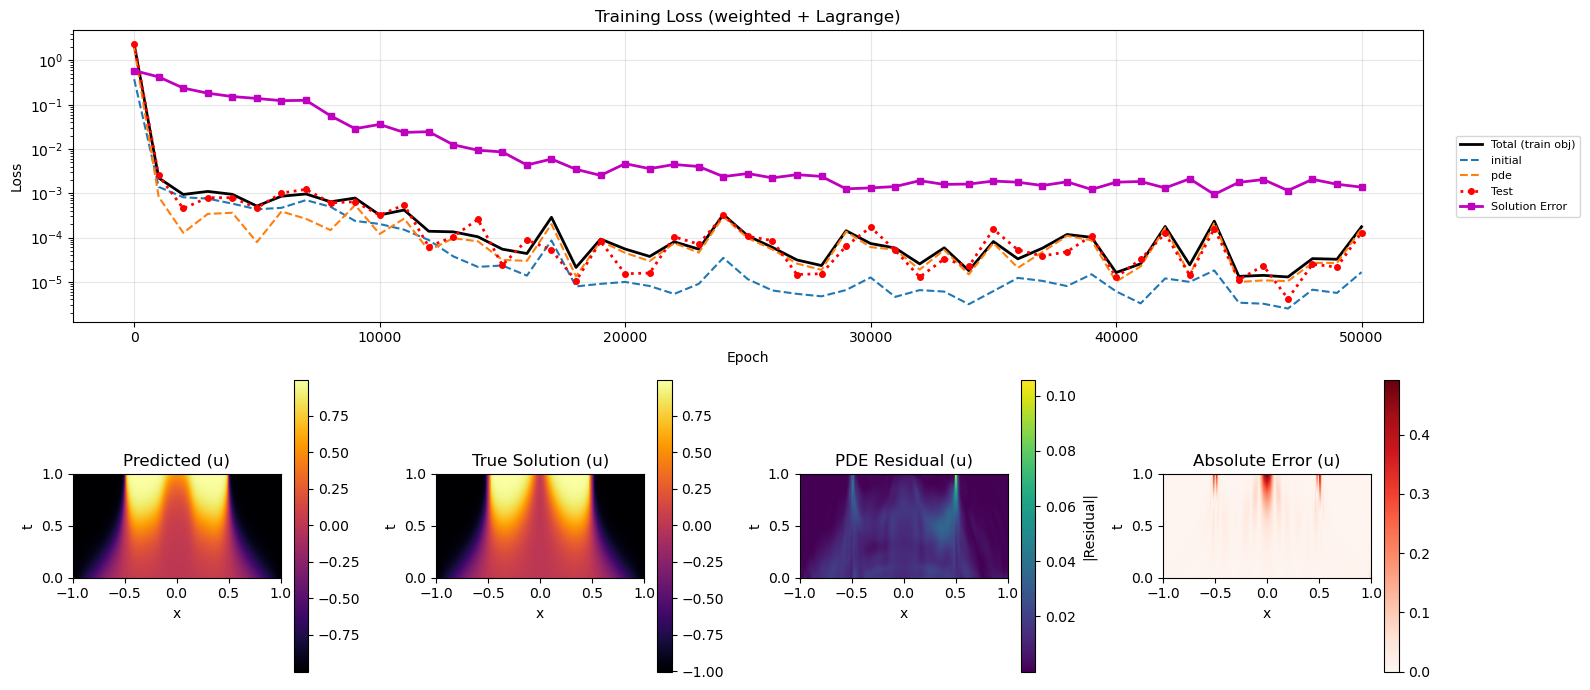

Epoch 0/50000 | Loss: 2.33e+00 | MSE: 2.33e+00 | Terms: [initial: 3.77e-01, pde: 1.95e+00] | Test Loss: 2.40e+00 | Error: 5.91e-01 | Time: 0.0s
Epoch 1000/50000 | Loss: 2.22e-03 | MSE: 2.22e-03 | Terms: [initial: 1.39e-03, pde: 8.27e-04] | Test Loss: 2.53e-03 | Error: 4.25e-01 | Time: 8.9s
Epoch 2000/50000 | Loss: 9.41e-04 | MSE: 9.41e-04 | Terms: [initial: 8.13e-04, pde: 1.28e-04] | Test Loss: 4.54e-04 | Error: 2.38e-01 | Time: 10.8s
Epoch 3000/50000 | Loss: 1.10e-03 | MSE: 1.10e-03 | Terms: [initial: 7.59e-04, pde: 3.43e-04] | Test Loss: 7.98e-04 | Error: 1.82e-01 | Time: 12.6s
Epoch 4000/50000 | Loss: 9.47e-04 | MSE: 9.47e-04 | Terms: [initial: 5.84e-04, pde: 3.63e-04] | Test Loss: 7.96e-04 | Error: 1.53e-01 | Time: 14.5s
Epoch 5000/50000 | Loss: 5.14e-04 | MSE: 5.14e-04 | Terms: [initial: 4.35e-04, pde: 7.88e-05] | Test Loss: 4.65e-04 | Error: 1.39e-01 | Time: 16.3s
Epoch 6000/50000 | Loss: 8.58e-04 | MSE: 8.58e-04 | Terms: [initial: 4.70e-04, pde: 3.89e-04] | Test Loss: 1.01e-03 |

In [6]:
trainer = pinns.Trainer(network, problem=problem)

trainer.set_solution(model_ac.predict)

trainer.compile(
    problem = {
        "pde":      {"train": 1000, "test": 10, "weight": 1.0},
        "initial":  {"train": 200,  "test": 10, "weight": 1.0},
    },
    # fit_problem_parameters=["coef"],
    optimizer=pinns.AdamOptimizer(learning_rate=1e-3),
    schedulers=[
        pinns.SchedulerResample(1),
        pinns.SchedulerCausal(term="pde", tol=1.0, n_chunks=16, t_col=1),
        # pinns.SchedulerLagrange(["pde"], lr=1e-3),
    ],
    epochs     = 50000,
    print_each = 1000,
)

trainer.train()